## Data cleaning and Preprocessing

In [227]:
# adding necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, PredefinedSplit
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
import time
warnings.filterwarnings("ignore")

In [228]:
# opening the dataset
data_filepath = "train_data/group_01_train.csv"
data = pd.read_csv(data_filepath)
data

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2019-02-27 16:33:43,25.885487,-80.209206,NaN,0.000,Lane blocked due to accident on I-95 Northboun...,I-95 S,Miami-Dade,FL,...,False,False,False,False,False,Day,Day,Day,Day,3
1,Source2,2019-07-16 14:48:06,33.652409,-112.093979,NaN,0.000,Accident on Bluefield Ave at 16th Ave.,N 16th Ave,Maricopa,AZ,...,False,False,False,False,False,Day,Day,Day,Day,2
2,Source1,2022-06-11 21:38:22,40.725697,-73.899985,-73.886415,0.728,Incident on I-495 EB near GRAND AVE Expect lon...,Long Island Expy E,Queens,NY,...,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2020-06-15 17:49:03,26.717860,-80.090410,-80.090410,0.000,At I-95 - Accident.,Palm Beach Lakes Blvd,Palm Beach,FL,...,False,False,False,False,False,Day,Day,Day,Day,2
4,Source2,2019-03-14 05:20:13,35.097069,-81.667786,NaN,0.000,Accident on I-85 Southbound after Exit 92 SC-11.,I-85 S,Cherokee,SC,...,False,False,False,False,False,Night,Night,Night,Night,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Source1,2021-06-08 11:16:30,39.748838,-78.182017,-78.184897,1.826,Stationary traffic on I-70 E - US-522 S from U...,Pigeon Cove Rd,Fulton,PA,...,False,False,False,False,False,Day,Day,Day,Day,2
99996,Source1,2021-11-27 11:38:11,38.677148,-120.918362,-120.945269,1.824,Accident on Shingle Springs Dr (US-50) from Ca...,El Dorado Fwy W,El Dorado,CA,...,False,False,False,False,False,Day,Day,Day,Day,2
99997,Source2,2019-08-01 06:05:23,32.895851,-96.899300,NaN,0.000,Accident on Royal Ln at Emerald St.,Emerald St,Dallas,TX,...,False,False,False,False,False,Night,Night,Night,Day,2
99998,Source1,2021-11-11 23:09:47,28.460345,-81.311589,-81.312289,0.058,Incident on NORTH FRONTAGE RD near FORBES PL R...,N Frontage Rd,Orange,FL,...,False,False,False,False,False,Night,Night,Night,Night,4


In [229]:
data.dtypes.unique()

array([<StringDtype(storage='python', na_value=nan)>, dtype('float64'),
       dtype('bool'), dtype('int64')], dtype=object)

In [230]:
# dropping f11 because the only value used in this column is is 'US'
data = data.drop(columns=['f11'])

In [231]:
# dropping f7 because converting it to a numerical value would need LLMs and NLPs which are not discussed in this course
data = data.drop(columns=['f7'])

In [232]:
# dropping f8 because of the same reason for the above cell
data = data.drop(columns=['f8'])

In [233]:
pd.DataFrame({
    'Dtype': data.dtypes,
    'Missing Count': data.isna().sum()
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

,Dtype,Missing Count
f5,float64,44062
f20,float64,28248
f14,float64,25749
f19,float64,7361
f17,float64,2258
f15,float64,2248
f21,str,2240
f18,str,2220
f16,float64,1767
f13,str,1517


In [234]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   f1      100000 non-null  str    
 1   f2      100000 non-null  str    
 2   f3      100000 non-null  float64
 3   f4      100000 non-null  float64
 4   f5      55938 non-null   float64
 5   f6      100000 non-null  float64
 6   f9      100000 non-null  str    
 7   f10     100000 non-null  str    
 8   f12     99898 non-null   str    
 9   f13     98483 non-null   str    
 10  f14     74251 non-null   float64
 11  f15     97752 non-null   float64
 12  f16     98233 non-null   float64
 13  f17     97742 non-null   float64
 14  f18     97780 non-null   str    
 15  f19     92639 non-null   float64
 16  f20     71752 non-null   float64
 17  f21     97760 non-null   str    
 18  f22     100000 non-null  bool   
 19  f23     100000 non-null  bool   
 20  f24     100000 non-null  bool   
 21  f25     100000 non-nul

In [235]:
data.nunique()

f1         3
f2     99754
f3     90627
f4     90664
f5     51835
f6      6155
f9      1290
f10       49
f12        4
f13    77827
f14      646
f15       99
f16      862
f17       48
f18       24
f19       75
f20      114
f21       82
f22        2
f23        2
f24        2
f25        2
f26        2
f27        2
f28        2
f29        2
f30        2
f31        2
f32        2
f33        2
f34        2
y          4
dtype: int64

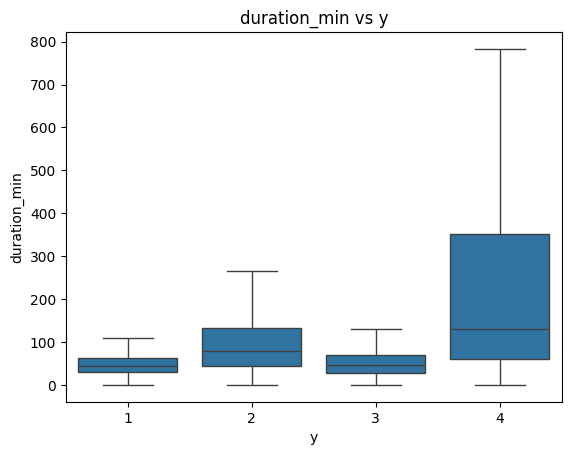

In [236]:
# we draw boxplot of dutation between f2 and f13 (f2 - f13) and see if there is any
# meaningful relation between y and this feature.

data['f13'] = pd.to_datetime(data['f13'], format='mixed')
data['f2'] = pd.to_datetime(data['f2'], format='mixed')

data['duration_min'] = (data['f2'] - data['f13']).dt.total_seconds() / 60.0

df_clean = data[data['duration_min'] > 0].copy()

sns.boxplot(data=df_clean, x='y', y='duration_min', showfliers=False)
plt.title('duration_min vs y')
plt.xlabel('y')
plt.ylabel('duration_min')
plt.show()

In [237]:
# we use f13 to extract hour, day of the week, and season of the record and save them in different columns.

data['f13'] = pd.to_datetime(data['f13'], format='mixed')

def get_season(month):
    if month in [12, 1, 2]:
        return 4
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3
    
data['hour'] = data['f13'].dt.hour
data['day_of_week'] = data['f13'].dt.dayofweek
data['season'] = data['f13'].dt.month.apply(get_season)

In [238]:
# we show the proportion of each target within each season and see if there is any
# meaningful relation between them.
pd.crosstab(data['season'], data['y'], normalize='index')

y,1,2,3,4
season,,,,
1,0.019418,0.766064,0.186306,0.028212
2,0.020251,0.746648,0.205400,0.027700
3,0.001172,0.815412,0.159126,0.024290
4,0.000280,0.836705,0.139527,0.023488


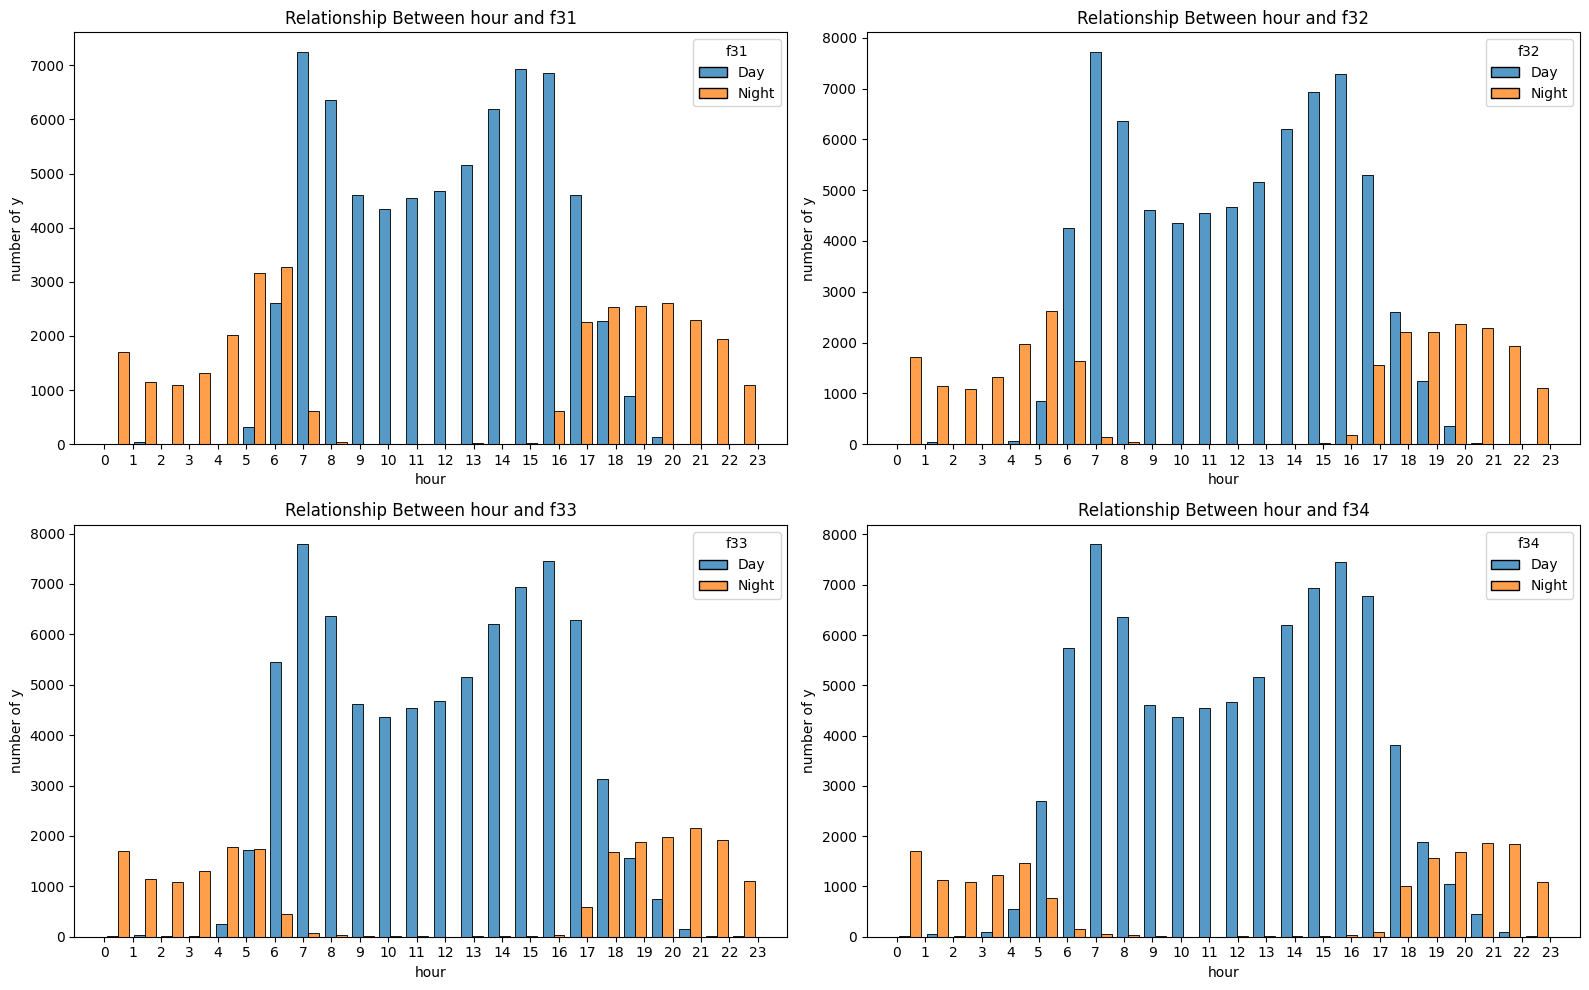

In [239]:
# we draw a histogram to see relationship between hour, and 4 columns which are Day/Night (f31, f32, f33, f34)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cols = ['f31', 'f32', 'f33', 'f34']
axes_flat = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=data, 
        x='hour', 
        hue=col, 
        multiple='dodge', 
        bins=24, 
        shrink=0.8, 
        ax=axes_flat[i]
    )
    axes_flat[i].set_title(f'Relationship Between hour and {col}')
    axes_flat[i].set_xlabel('hour')
    axes_flat[i].set_ylabel('number of y')
    axes_flat[i].set_xticks(range(0, 24))


plt.tight_layout()
fig.savefig('hour_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [240]:
# we drop these 4 columns becuase they show high colinearity with `hour`
data = data.drop(columns=['f31', 'f32', 'f33', 'f34'])

In [241]:
# we drop these f2 and f13 cause their information is extracted and they're not needed anymore.
data = data.drop(columns=['f2', 'f13'])
data.columns

Index(['f1', 'f3', 'f4', 'f5', 'f6', 'f9', 'f10', 'f12', 'f14', 'f15', 'f16',
       'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26',
       'f27', 'f28', 'f29', 'f30', 'y', 'duration_min', 'hour', 'day_of_week',
       'season'],
      dtype='str')

In [242]:
# Dropping duplicates from the training set
print("before deduplication:", len(data))
data = data.drop_duplicates()
print("after deduplication:", len(data))

before deduplication: 100000
after deduplication: 99939


In [243]:
# splitting the dataset into 15% test, 15% validation and 70% training sets

X = data.drop(columns=['y'])
y = data['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=123, stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=123, stratify=y_temp
)

print(f"Training set:   {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation set: {X_val.shape}, Labels: {y_val.shape}")
print(f"Test set:       {X_test.shape}, Labels: {y_test.shape}")

Training set:   (69957, 29), Labels: (69957,)
Validation set: (14991, 29), Labels: (14991,)
Test set:       (14991, 29), Labels: (14991,)


In [244]:
alpha = 0.05
missing_percentage = X_train.isnull().mean() * 100
over_miss_cols = missing_percentage[missing_percentage > 25].index

print("Checking Missingness")

cols_to_drop = []
cols_to_keep_and_impute = {}

for col in over_miss_cols:
    missing_indicator_train = X_train[col].isna().astype(int)
    contingency_table = pd.crosstab(missing_indicator_train, y_train)

    contingency_table = pd.crosstab(
        missing_indicator_train,
        y_train,
        rownames=["Is_Missing"],
        colnames=["Target_y"],
    )

    print()
    print("=" * 50)
    print(f"Column: '{col}'")
    print("-" * 50)
    print("Contingency Table (Counts):")
    print(contingency_table)
    print("-" * 50)


    if (contingency_table == 0).any().any() :
        print(f"Column: '{col}' - Skipping test.")
     
        cols_to_drop.append(col)
        continue

    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    print(f"Column: '{col}' | p-value: {p_value:.5f}")

    if p_value < alpha:
        print(
            f"Missingness is RELATED to 'y' (p < {alpha}). Keeping the column and impuation info for later."
        )
        
        if pd.api.types.is_numeric_dtype(X_train[col]):
            fill_val = X_train[col].median()
            print(
                f"-> New indicator column '{col}_is_missing' and imputed '{col}' with median ('{fill_val}')."
            )
        else:
            fill_val = "[MISSING]"
            print(
                f"-> New indicator column '{col}_is_missing' and imputed '{col}' with new category '{fill_val}'."
            )

        cols_to_keep_and_impute[col] = fill_val

    else:
        print(
            f"-> Marking column for dropping."
        )
        cols_to_drop.append(col)

for df in [X_train, X_val, X_test]:
    for col, fill_val in cols_to_keep_and_impute.items():
        df[f"{col}_is_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(fill_val)
    
    df.drop(columns=cols_to_drop, inplace=True)


Checking Missingness

Column: 'f5'
--------------------------------------------------
Contingency Table (Counts):
Target_y      1      2      3     4
Is_Missing                         
0           278  35673   1489  1660
1           352  20014  10357   134
--------------------------------------------------
Column: 'f5' | p-value: 0.00000
Missingness is RELATED to 'y' (p < 0.05). Keeping the column and impuation info for later.
-> New indicator column 'f5_is_missing' and imputed 'f5' with median ('-88.0802355').

Column: 'f14'
--------------------------------------------------
Contingency Table (Counts):
Target_y      1      2     3     4
Is_Missing                        
0           616  43533  6532  1286
1            14  12154  5314   508
--------------------------------------------------
Column: 'f14' | p-value: 0.00000
Missingness is RELATED to 'y' (p < 0.05). Keeping the column and impuation info for later.
-> New indicator column 'f14_is_missing' and imputed 'f14' with median ('

In [245]:
remaining_missing = X_train.isnull().mean() * 100
cols_to_impute = remaining_missing[remaining_missing > 0].index

num_cols = X_train[cols_to_impute].select_dtypes(include='number').columns
if not num_cols.empty:
    num_imputer = SimpleImputer(strategy='mean')
    X_train.loc[:, num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_val.loc[:, num_cols] = num_imputer.transform(X_val[num_cols])
    X_test.loc[:, num_cols] = num_imputer.transform(X_test[num_cols])

    for col, mean_val in zip(num_cols, num_imputer.statistics_):
        print(f"Imputating numerical column {col} with {mean_val}")


cat_cols = X_train[cols_to_impute].select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    fill_label = "Unknown"
    existing_values = X_train[col].dropna().unique()
    if fill_label in existing_values:
        i = 1
        while f"Unknown_{i}" in existing_values:
            i += 1
        fill_label = f"Unknown_{i}"

    print(f"Imputating string column {col} with {fill_label}")
    X_train[col] = X_train[col].fillna(fill_label)
    X_val[col] = X_val[col].fillna(fill_label)
    X_test[col] = X_test[col].fillna(fill_label)


Imputating numerical column f15 with 64.75112494156147
Imputating numerical column f16 with 29.54104170908351
Imputating numerical column f17 with 9.104303379326474
Imputating numerical column f19 with 7.642127882438116
Imputating numerical column duration_min with 589.3808986781158
Imputating numerical column hour with 12.051956717240579
Imputating numerical column day_of_week with 2.5963708624641004
Imputating string column f12 with Unknown
Imputating string column f18 with Unknown
Imputating string column f21 with Unknown


In [246]:
# mean imputer for numerical numbers on the trainig dataset, as well as for validation and test separately

numeric_cols = X_train.select_dtypes(include='number').columns
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train[numeric_cols])

X_train.loc[:, numeric_cols] = imputer.transform(X_train[numeric_cols])
X_val.loc[:, numeric_cols] = imputer.transform(X_val[numeric_cols])
X_test.loc[:, numeric_cols] = imputer.transform(X_test[numeric_cols])

In [247]:
# frequency encoding for text dtype high cardinality columns
cols = ['f9', 'f10', 'f18', 'f21']

for col in cols:
    freq = X_train[col].value_counts()
    
    X_train[col] = X_train[col].map(freq).astype(int)
    X_val[col] = X_val[col].map(freq).fillna(0).astype(int)
    X_test[col] = X_test[col].map(freq).fillna(0).astype(int)
    
    print(f"Frequency encoded {col}")


Frequency encoded f9
Frequency encoded f10
Frequency encoded f18
Frequency encoded f21


In [248]:
# ont-hot-oncoding for text dtype categorical columns
cols = ['f1', 'f12']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

train_encoded = ohe.fit_transform(X_train[cols])
val_encoded = ohe.transform(X_val[cols])
test_encoded = ohe.transform(X_test[cols])

feature_names = ohe.get_feature_names_out(cols)
train_encoded_df = pd.DataFrame(train_encoded, columns=feature_names, index=X_train.index)
val_encoded_df = pd.DataFrame(val_encoded, columns=feature_names, index=X_val.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=feature_names, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cols), train_encoded_df], axis=1)
X_val = pd.concat([X_val.drop(columns=cols), val_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=cols), test_encoded_df], axis=1)

In [249]:
# Converting boolean columns to integers for ML compatibility
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_val[bool_cols] = X_val[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [250]:
# columns standardization
num_cols = X_train.select_dtypes(include='number').columns

X_train[num_cols] = X_train[num_cols].astype(float)
X_val[num_cols] = X_val[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols]).round(2)
X_val[num_cols] = scaler.transform(X_val[num_cols]).round(2)
X_test[num_cols] = scaler.transform(X_test[num_cols]).round(2)

In [251]:
# Tree-Based RFC Feature selection
rf_model = RandomForestClassifier(n_estimators=100, random_state=123, n_jobs=-1)

selector = SelectFromModel(estimator=rf_model, max_features=25, threshold=-np.inf)

selector.fit(X_train, y_train)

selected_cols = X_train.columns[selector.get_support()]
dropped_cols = [col for col in X_train.columns if col not in selected_cols]

X_train_selected = selector.transform(X_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

X_train = pd.DataFrame(X_train_selected, columns=selected_cols, index=X_train.index)
X_val = pd.DataFrame(X_val_selected, columns=selected_cols, index=X_val.index)
X_test = pd.DataFrame(X_test_selected, columns=selected_cols, index=X_test.index)

print(f"Features reduced from 31 to {X_train.shape[1]}")
print(f"feature dropped: {dropped_cols}")

Features reduced from 31 to 25
feature dropped: ['f20', 'f22', 'f24', 'f26', 'f27', 'f28', 'f29', 'f1_Source3', 'f12_US/Central', 'f12_US/Eastern', 'f12_US/Mountain', 'f12_US/Pacific', 'f12_Unknown']


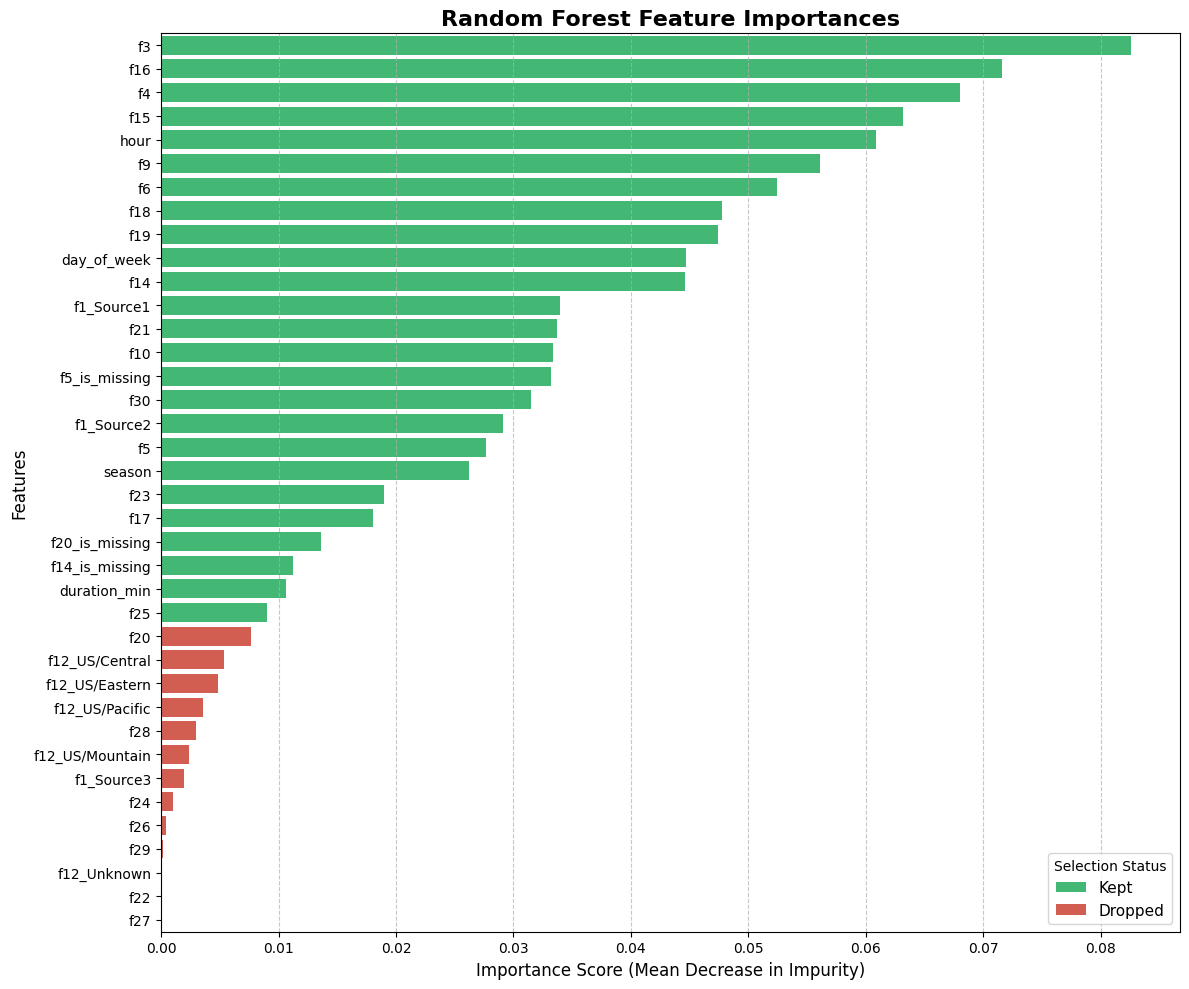

In [252]:
# important features visualized by our FS method
trained_rf = selector.estimator_
importances = trained_rf.feature_importances_
original_features = selector.feature_names_in_

importance_df = pd.DataFrame({
    'Feature': original_features,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df['Status'] = ['Kept' if feat in selected_cols else 'Dropped' for feat in importance_df['Feature']]

plt.figure(figsize=(12, 10))
sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Feature', 
    hue='Status',
    dodge=False,
    palette={'Kept': '#2ecc71', 'Dropped': '#e74c3c'} 
)

plt.title('Random Forest Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.legend(title='Selection Status', loc='lower right', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [253]:
train_final = pd.concat([X_train, y_train], axis=1)
val_final = pd.concat([X_val, y_val], axis=1)
test_final = pd.concat([X_test, y_test], axis=1)

print("\n--- Final Dataset Shapes ---")
print(f"Training Data:   {train_final.shape}")
print(f"Validation Data: {val_final.shape}")
print(f"Test Data:       {test_final.shape}")

train_final.to_csv('train_data/train_preprocessed.csv', index=False)
val_final.to_csv('train_data/val_preprocessed.csv', index=False)
test_final.to_csv('train_data/test_preprocessed.csv', index=False)


--- Final Dataset Shapes ---
Training Data:   (69957, 26)
Validation Data: (14991, 26)
Test Data:       (14991, 26)


In [254]:
# scale: 1 = worst/complex to 10 = best/interpretable
quality = {
    "Multinomial Logistic Regression": {
        "Interpretability": 10.0,
        "Complexity_Robustness": 10.0,
        "Data_Alignment": 5.0,
    },
    "XGBoost": {
        "Interpretability": 6.0,
        "Complexity_Robustness": 6.0,
        "Data_Alignment": 10.0,
    },
    "Multi-Layer Perceptron": {
        "Interpretability": 2.0,
        "Complexity_Robustness": 4.0,
        "Data_Alignment": 8.0,
    }
}

weights = {
    "Performance": 0.35,
    "Interpretability": 0.20,
    "Complexity_Robustness": 0.15,
    "Computational_Efficiency": 0.15,
    "Data_Alignment": 0.15
}

In [255]:
X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

In [256]:
# setup train and validaition sets for hyperparameter tuning
X_tune = np.vstack((X_train, X_val))
y_tune = np.concatenate((y_train_encoded, y_val_encoded))

split_index = np.zeros(X_tune.shape[0])
split_index[:len(X_train)] = -1
split_index[len(X_train):] = 0

pds = PredefinedSplit(test_fold=split_index)

print(f"Tuning setup complete. Combined training samples: {len(X_train)}, validation samples: {len(X_val)}")

Tuning setup complete. Combined training samples: 69957, validation samples: 14991


In [257]:
# randomized search for logistic regression
print("Tuning Multinomial Logistic Regression...")

logreg_dist = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0],
    'penalty': ['l2']
}

logreg_base = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=123)

logreg_search = RandomizedSearchCV(
    estimator=logreg_base,
    param_distributions=logreg_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=pds,
    random_state=123,
    n_jobs=-1
)

logreg_search.fit(X_tune, y_tune)
best_logreg_params = logreg_search.best_params_
print("Best Logistic Regression Parameters:", best_logreg_params)
print(f"Best Validation Weighted F1: {logreg_search.best_score_:.4f}")

Tuning Multinomial Logistic Regression...


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

Best Logistic Regression Parameters: {'penalty': 'l2', 'C': 100.0}
Best Validation Weighted F1: 0.4656


In [258]:
# randomized search for XGBoost
print("Tuning XGBoost Classifier...")

xgb_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_base = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=123)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=pds,
    random_state=123,
    n_jobs=-1
)

xgb_search.fit(X_tune, y_tune)
best_xgb_params = xgb_search.best_params_
print("Best XGBoost Parameters:", best_xgb_params)
print(f"Best Validation Weighted F1: {xgb_search.best_score_:.4f}")

Tuning XGBoost Classifier...
Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Validation Weighted F1: 0.8378


In [259]:
# randomized search for MLP
print("Tuning Multi-Layer Perceptron...")

mlp_dist = {
    'hidden_layer_sizes': [(64,), (128, 64), (64, 32)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

mlp_base = MLPClassifier(activation='relu', solver='adam', max_iter=1000, random_state=123)

mlp_search = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=mlp_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=pds,
    random_state=123,
    n_jobs=-1
)

mlp_search.fit(X_tune, y_tune)
best_mlp_params = mlp_search.best_params_
print("Best MLP Parameters:", best_mlp_params)
print(f"Best Validation Weighted F1: {mlp_search.best_score_:.4f}")

Tuning Multi-Layer Perceptron...
Best MLP Parameters: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (64,), 'alpha': 0.001}
Best Validation Weighted F1: 0.8100


In [260]:
# training
models = {
    "Multinomial Logistic Regression": LogisticRegression(
        solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=123,
        **best_logreg_params
    ),
    "XGBoost": XGBClassifier(
        objective='multi:softmax', eval_metric='mlogloss', random_state=123,
        **best_xgb_params
    ),
    "Multi-Layer Perceptron": MLPClassifier(
        activation='relu', solver='adam', max_iter=1000, random_state=123,
        **best_mlp_params
    )
}

results = {}

print("Starting Model Training...")
print("-" * 50)

for name, model in models.items():
    print(f"Executing: {name}")
    
    start_time = time.perf_counter()
    model.fit(X_train, y_train_encoded)
    y_val_pred = model.predict(X_val)
    end_time = time.perf_counter()
    
    elapsed_time = end_time - start_time
    
    val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
    val_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')
    
    results[name] = {
        "F1-Score": val_f1,
        "Accuracy": val_accuracy,
        "Execution_Time": elapsed_time
    }

raw_times = [res["Execution_Time"] for res in results.values()]
min_time, max_time = min(raw_times), max(raw_times)

Starting Model Training...
--------------------------------------------------
Executing: Multinomial Logistic Regression
Executing: XGBoost
Executing: Multi-Layer Perceptron


In [261]:
# calculate score based with mcda method for our final model proposal
mcda_records = []

for name, results in results.items():
    perf_score = results["F1-Score"] * 10.0
    
    if max_time == min_time:
        time_score = 10.0
    else:
        time_score = 1.0 + 9.0 * (1.0 - (results["Execution_Time"] - min_time) / (max_time - min_time))
        
    quals = quality[name]
    
    weighted_score = (
        weights["Performance"] * perf_score +
        weights["Interpretability"] * quals["Interpretability"] +
        weights["Complexity_Robustness"] * quals["Complexity_Robustness"] +
        weights["Computational_Efficiency"] * time_score +
        weights["Data_Alignment"] * quals["Data_Alignment"]
    )
    
    mcda_records.append({
        "Model": name,
        "Validation F1": round(results["F1-Score"], 4),
        "Raw Exec Time (s)": round(results["Execution_Time"], 3),
        "S_Performance": round(perf_score, 2),
        "S_Interpretability": quals["Interpretability"],
        "S_Complexity": quals["Complexity_Robustness"],
        "S_Efficiency": round(time_score, 2),
        "S_Alignment": quals["Data_Alignment"],
        "Final Decision Score": round(weighted_score, 3)
    })

decision_df = pd.DataFrame(mcda_records).sort_values(by="Final Decision Score", ascending=False)

print()
print("=" * 80)
print(decision_df.to_string(index=False))
print("=" * 80)

optimal_model_name = decision_df.iloc[0]["Model"]
print()
print(f"Optimal Model Selected for project: {optimal_model_name}")


                          Model  Validation F1  Raw Exec Time (s)  S_Performance  S_Interpretability  S_Complexity  S_Efficiency  S_Alignment  Final Decision Score
                        XGBoost         0.8378              3.592           8.38                 6.0           6.0          5.74         10.0                 7.394
Multinomial Logistic Regression         0.4656              0.878           4.66                10.0          10.0         10.00          5.0                 7.379
         Multi-Layer Perceptron         0.8100              6.619           8.10                 2.0           4.0          1.00          8.0                 5.185

Optimal Model Selected for project: XGBoost


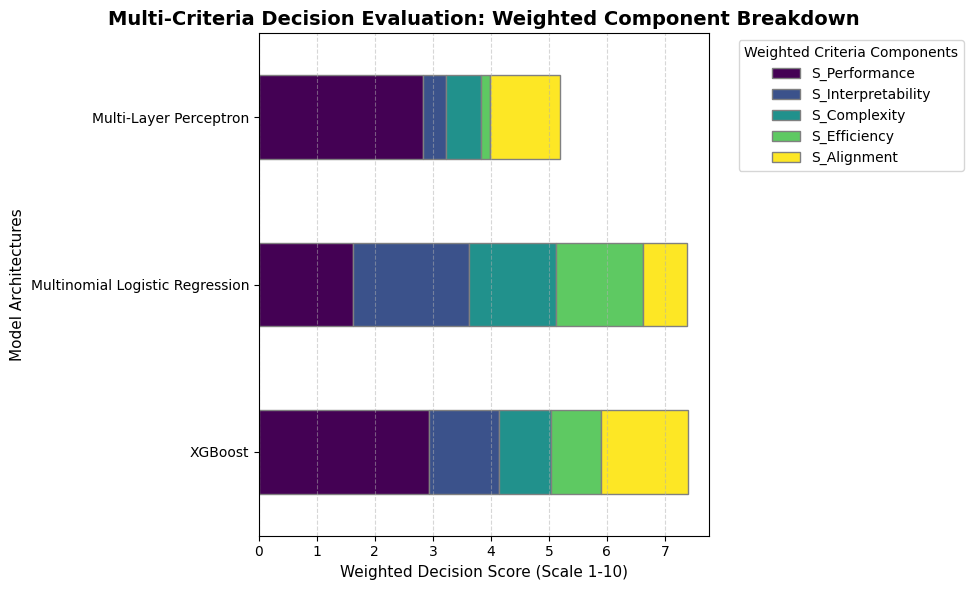

In [262]:
# create a chart of scores for the report
score_cols = ["S_Performance", "S_Interpretability", "S_Complexity", "S_Efficiency", "S_Alignment"]
plot_df = decision_df.set_index("Model")[score_cols]

for col in score_cols:
    weight_key = {
        "S_Performance": "Performance",
        "S_Interpretability": "Interpretability",
        "S_Complexity": "Complexity_Robustness",
        "S_Efficiency": "Computational_Efficiency",
        "S_Alignment": "Data_Alignment"
    }[col]
    plot_df[col] = plot_df[col] * weights[weight_key]

plt.figure(figsize=(10, 6))
plot_df.plot(kind='barh', stacked=True, colormap='viridis', edgecolor='grey', ax=plt.gca())
plt.title("Multi-Criteria Decision Evaluation: Weighted Component Breakdown", fontsize=14, fontweight='bold')
plt.xlabel("Weighted Decision Score (Scale 1-10)", fontsize=11)
plt.ylabel("Model Architectures", fontsize=11)
plt.legend(title="Weighted Criteria Components", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('decision_framework_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

In [263]:
winning_model = models[optimal_model_name] 


y_test_pred = winning_model.predict(X_test)
final_test_f1 = f1_score(y_test_encoded, y_test_pred, average='weighted')
final_test_acc = accuracy_score(y_test_encoded, y_test_pred)

print(f"--- TEST EVALUATION FOR {optimal_model_name.upper()} ---")
print(f"Test F1-Score: {final_test_f1:.4f}")
print(f"Test Accuracy: {final_test_acc:.4f}")

--- TEST EVALUATION FOR XGBOOST ---
Test F1-Score: 0.8353
Test Accuracy: 0.8501
